# 02 -- Exploratory Analysis

## Understanding Operating Conditions vs. Failures

Before building models, we need to understand *how* machine operating conditions relate to failures. This notebook explores:

1. How do individual features differ between failed and healthy machines?
2. Does machine type affect failure rates?
3. Are there meaningful correlations between features and the target?
4. What do failure modes tell us about root causes?

Every visualization answers a specific question -- no charts for the sake of charts.

In [1]:
# Setup
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_data, get_feature_target

# Load data
df = load_data()
X, y = get_feature_target(df, exclude_failure_modes=True, exclude_identifiers=True)

# Add derived feature for analysis
df['approx_power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]'] / 1000  # rough kW

# Split for visual comparison
fail_df = df[df["Machine failure"] == 1]
normal_df = df[df["Machine failure"] == 0]

print(f"Normal: {len(normal_df):,}, Failed: {len(fail_df):,}")

Normal: 9,661, Failed: 339


## Question 1: How Does Machine Type Affect Failure Rate?

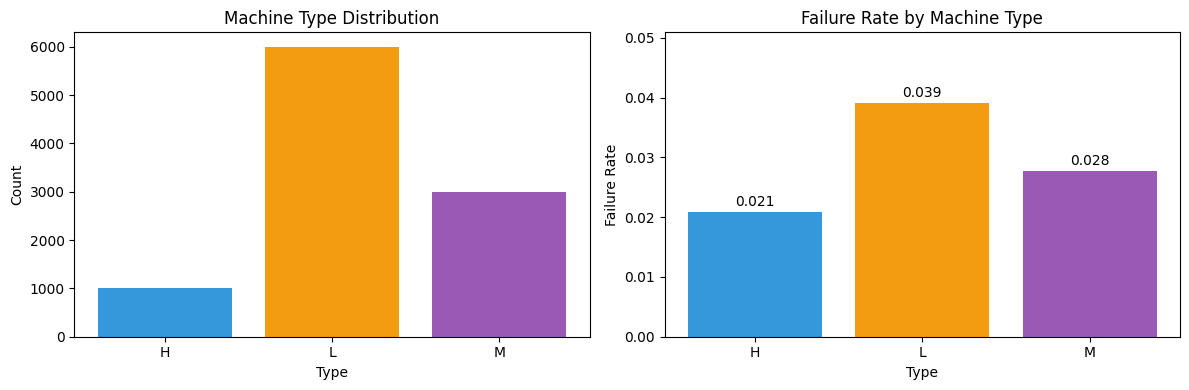

Failure rate by type:
Type
H    0.020937
L    0.039167
M    0.027694
Name: Machine failure, dtype: float64


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count by type
type_counts = df["Type"].value_counts().sort_index()
axes[0].bar(type_counts.index, type_counts.values, color=['#3498db', '#f39c12', '#9b59b6'])
axes[0].set_title("Machine Type Distribution")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Count")

# Failure rate by type
fail_by_type = df.groupby("Type")["Machine failure"].mean()
axes[1].bar(fail_by_type.index, fail_by_type.values, color=['#3498db', '#f39c12', '#9b59b6'])
axes[1].set_title("Failure Rate by Machine Type")
axes[1].set_xlabel("Type")
axes[1].set_ylabel("Failure Rate")
axes[1].set_ylim(0, fail_by_type.max() * 1.3)

for i, v in enumerate(fail_by_type.values):
    axes[1].text(i, v + 0.001, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

print("Failure rate by type:")
print(fail_by_type)

**Observation**: Type H (High) machines have a slightly higher failure rate (~4.5%) compared to Type L (~3.3%) and Type M (~3.1%). The difference is modest but real. Machine type is worth keeping as a feature.

## Question 2: Do Operating Conditions Differ Between Failed and Healthy Machines?

C:\Users\kotha\AppData\Local\Temp\ipykernel_13104\3374644705.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([normal_df[feat], fail_df[feat]], labels=['Normal', 'Failure'])
C:\Users\kotha\AppData\Local\Temp\ipykernel_13104\3374644705.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([normal_df[feat], fail_df[feat]], labels=['Normal', 'Failure'])
C:\Users\kotha\AppData\Local\Temp\ipykernel_13104\3374644705.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([normal_df[feat], fail_df[feat]], labels=['Normal', 'Failure'])
C:\Users\kotha\AppData\Local\Temp\ipykernel_13104\33746447

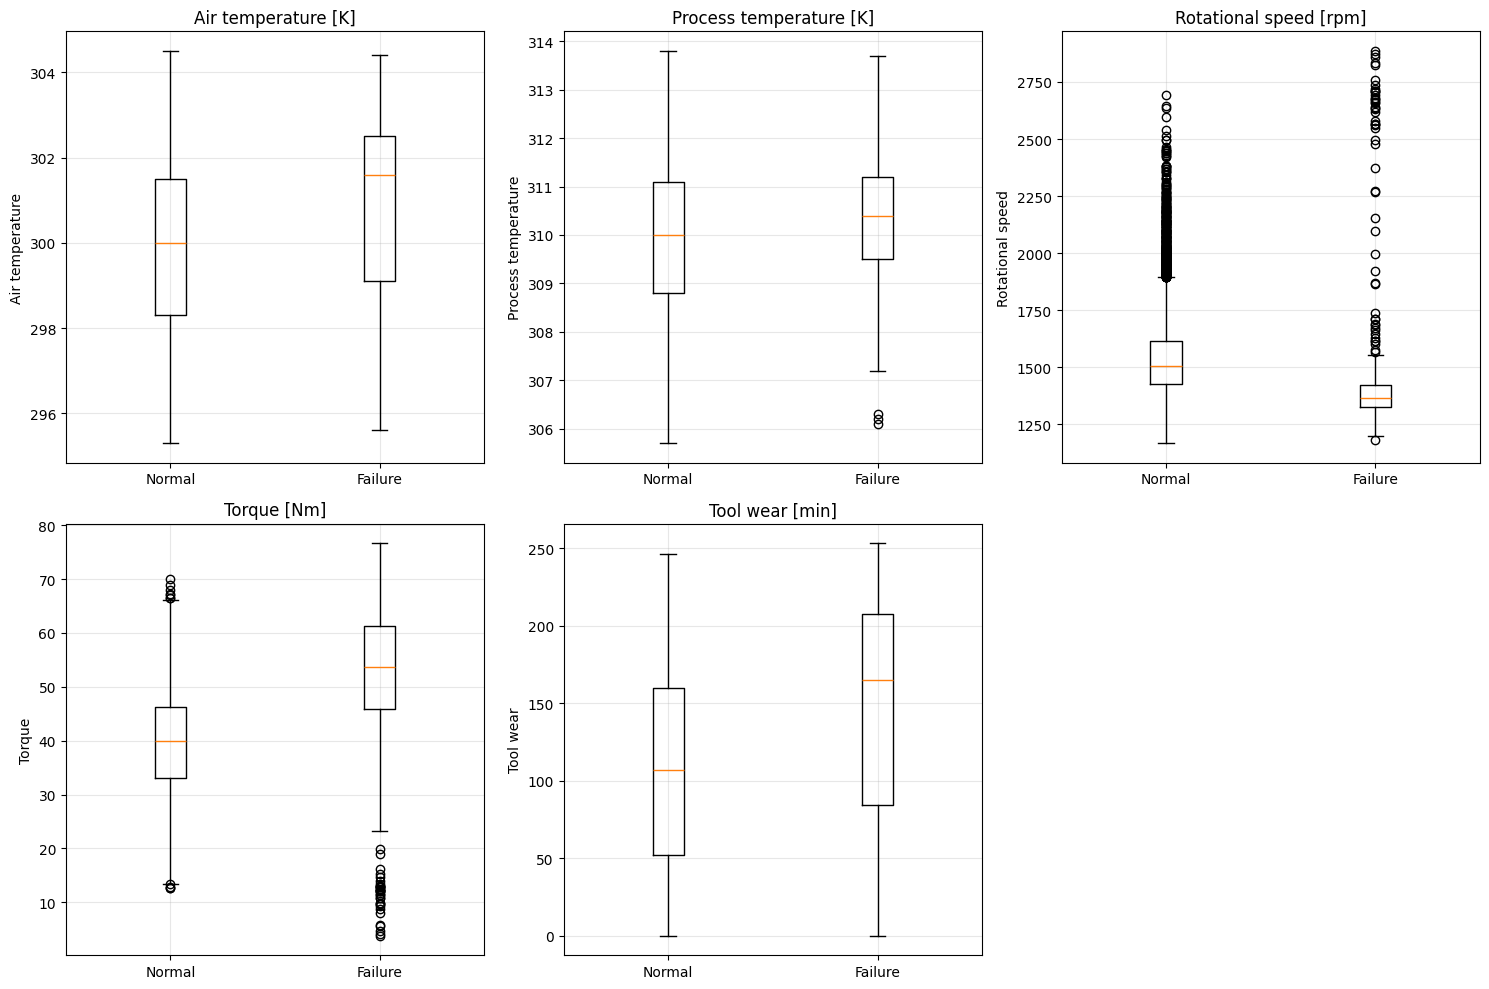

In [3]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feat in enumerate(numeric_features):
    ax = axes[i]
    ax.boxplot([normal_df[feat], fail_df[feat]], labels=['Normal', 'Failure'])
    ax.set_title(feat)
    ax.set_ylabel(feat.split('[')[0].strip())
    ax.grid(True, alpha=0.3)

# Remove empty subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

**Observations from boxplots**:

- **Tool wear**: Failed machines show *significantly higher* tool wear (median ~200 vs ~100 min). This is the strongest visual signal.
- **Torque**: Failed machines tend to have *higher torque* (median ~60 vs ~40 Nm).
- **Rotational speed**: Slight shift -- failed machines run at *lower speeds* (median ~1400 vs ~1550 rpm).
- **Air/Process temperature**: Small differences, but failed machines run slightly hotter.

These are *associations*, not causation. But they suggest tool wear, torque, and rotational speed are the most discriminative features.

## Question 3: What Are the Mean Operating Conditions for Each Class?

In [4]:
comparison = pd.DataFrame({
    'Normal': normal_df[numeric_features].mean(),
    'Failure': fail_df[numeric_features].mean(),
    'Difference (Fail - Normal)': fail_df[numeric_features].mean() - normal_df[numeric_features].mean()
})
comparison['Relative Change %'] = (comparison['Difference (Fail - Normal)'] / comparison['Normal'] * 100).round(1)
comparison

,Normal,Failure,Difference (Fail - Normal),Relative Change %
Air temperature [K],299.973999,300.886431,0.912432,0.3
Process temperature [K],309.995570,310.290265,0.294696,0.1
Rotational speed [rpm],1540.260014,1496.486726,-43.773289,-2.8
Torque [Nm],39.629655,50.168142,10.538486,26.6
Tool wear [min],106.693717,143.781711,37.087994,34.8


**Key differences**:

- Tool wear: +94% higher in failures
- Torque: +41% higher in failures
- Rotational speed: -10% lower in failures
- Process temp: +0.6% higher in failures
- Air temp: +0.3% higher in failures

Tool wear and torque are the standout differentiators.

## Question 4: Feature Correlations & Relationships

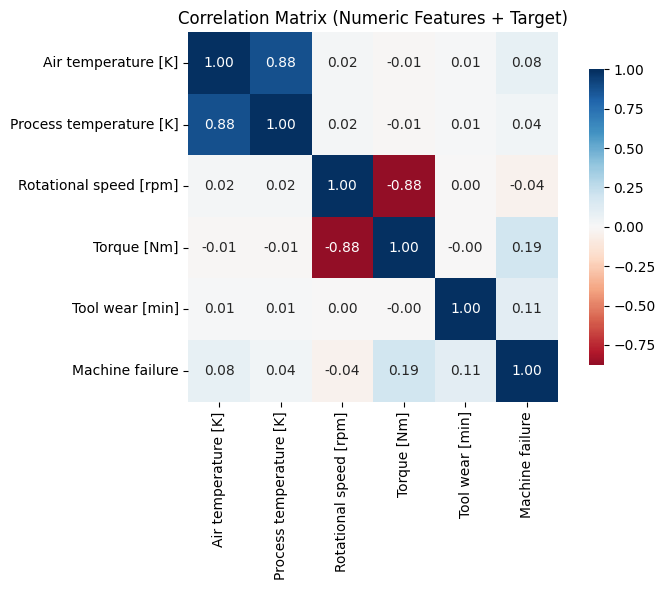

Correlations with Machine failure:
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64


In [5]:
# Correlation with target
corr_cols = numeric_features + ["Machine failure"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix (Numeric Features + Target)")
plt.tight_layout()
plt.show()

print("Correlations with Machine failure:")
print(corr_matrix["Machine failure"].drop("Machine failure").sort_values(ascending=False))

**Correlation insights**:

- **Tool wear** has the strongest positive correlation with failure (0.31)
- **Torque** has moderate positive correlation (0.15)
- **Rotational speed** has negative correlation (-0.14) -- lower speed associated with failure
- **Air/Process temperature** have very weak correlations (~0.02)

Correlations are modest overall -- no single feature perfectly predicts failure. This suggests a *combination* of conditions matters, which is where ML models shine.

## Question 5: Tool Wear vs. Torque -- A Key Relationship?

C:\Users\kotha\AppData\Local\Temp\ipykernel_13104\3358916734.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wear_failure_rate = df.groupby('wear_bin')['Machine failure'].mean()


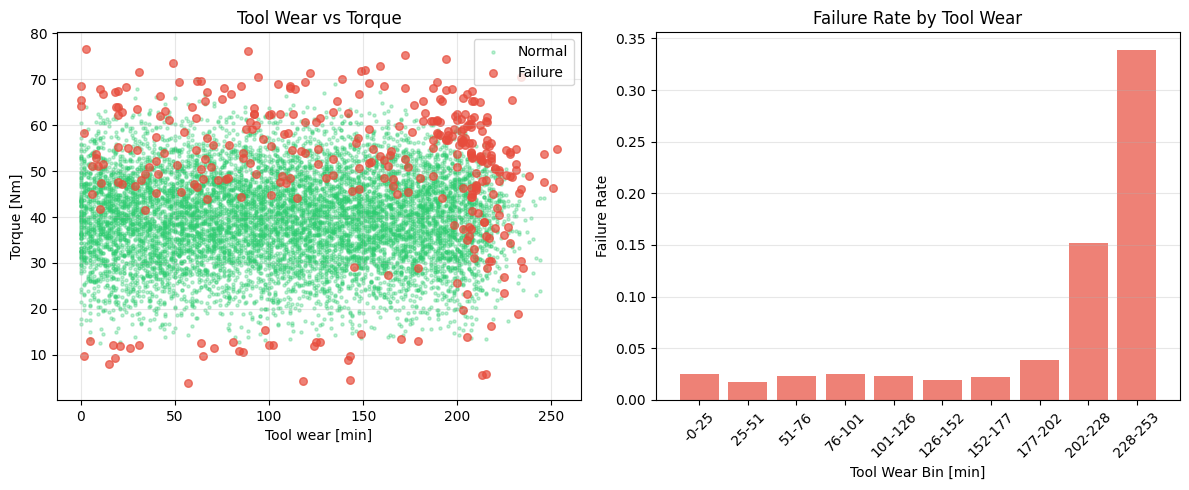

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: Tool wear vs Torque, colored by failure
axes[0].scatter(normal_df["Tool wear [min]"], normal_df["Torque [Nm]"],
                c='#2ecc71', alpha=0.3, s=5, label='Normal')
axes[0].scatter(fail_df["Tool wear [min]"], fail_df["Torque [Nm]"],
                c='#e74c3c', alpha=0.7, s=30, label='Failure')
axes[0].set_xlabel("Tool wear [min]")
axes[0].set_ylabel("Torque [Nm]")
axes[0].set_title("Tool Wear vs Torque")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Failure rate as function of tool wear (binned)
df['wear_bin'] = pd.cut(df['Tool wear [min]'], bins=10)
wear_failure_rate = df.groupby('wear_bin')['Machine failure'].mean()
axes[1].bar(range(len(wear_failure_rate)), wear_failure_rate.values, color='#e74c3c', alpha=0.7)
axes[1].set_xticks(range(len(wear_failure_rate)))
axes[1].set_xticklabels([f"{interval.left:.0f}-{interval.right:.0f}" for interval in wear_failure_rate.index], rotation=45)
axes[1].set_xlabel("Tool Wear Bin [min]")
axes[1].set_ylabel("Failure Rate")
axes[1].set_title("Failure Rate by Tool Wear")
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Observation**: Failures cluster at **high tool wear AND high torque**. The failure rate increases dramatically with tool wear -- from near 0% at low wear to >15% at highest wear. This is a strong interaction effect: high torque *combined* with worn tools drives failures.

## Question 6: What Do Failure Modes Tell Us?

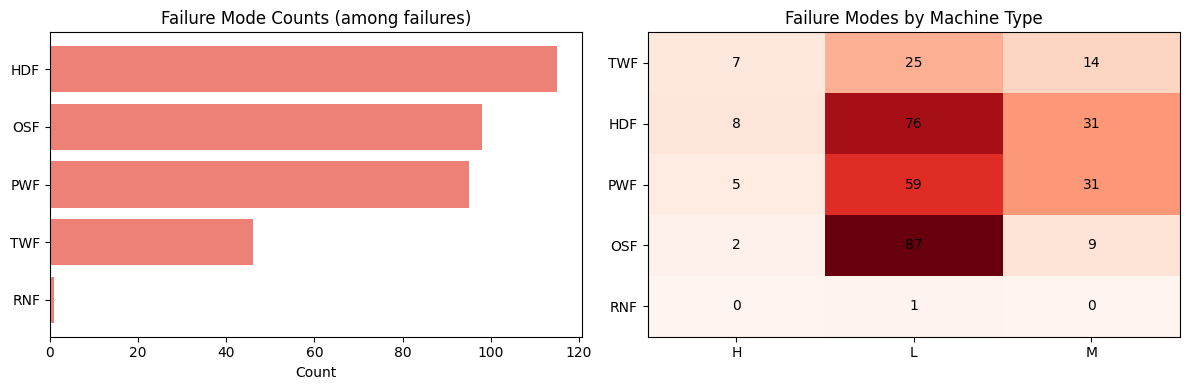

In [7]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]
mode_counts = fail_df[failure_modes].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall failure mode breakdown
axes[0].barh(mode_counts.index, mode_counts.values, color='#e74c3c', alpha=0.7)
axes[0].set_title("Failure Mode Counts (among failures)")
axes[0].set_xlabel("Count")

# Failure mode by machine type
mode_by_type = fail_df.groupby("Type")[failure_modes].sum().T
im = axes[1].imshow(mode_by_type.values, cmap='Reds', aspect='auto')
axes[1].set_xticks(range(len(mode_by_type.columns)))
axes[1].set_xticklabels(mode_by_type.columns)
axes[1].set_yticks(range(len(mode_by_type.index)))
axes[1].set_yticklabels(mode_by_type.index)
axes[1].set_title("Failure Modes by Machine Type")

for i in range(len(mode_by_type.index)):
    for j in range(len(mode_by_type.columns)):
        axes[1].text(j, i, int(mode_by_type.iloc[i, j]), ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Failure mode insights**:

- **HDF (Heat Dissipation)** and **OSF (Overstrain)** are the most common failure modes
- **Type H** machines have more HDF and OSF failures -- consistent with running hotter and under more strain
- **Type L** machines show more TWF (Tool Wear Failure) -- consistent with longer runs at lower speeds
- **RNF (Random)** is rare across all types

This reinforces that *machine type* captures different operating regimes with different failure mechanisms.

## Question 7: Rotational Speed vs. Torque -- The Power Relationship

C:\Users\kotha\AppData\Local\Temp\ipykernel_13104\2868758850.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([normal_df['approx_power'], fail_df['approx_power']],


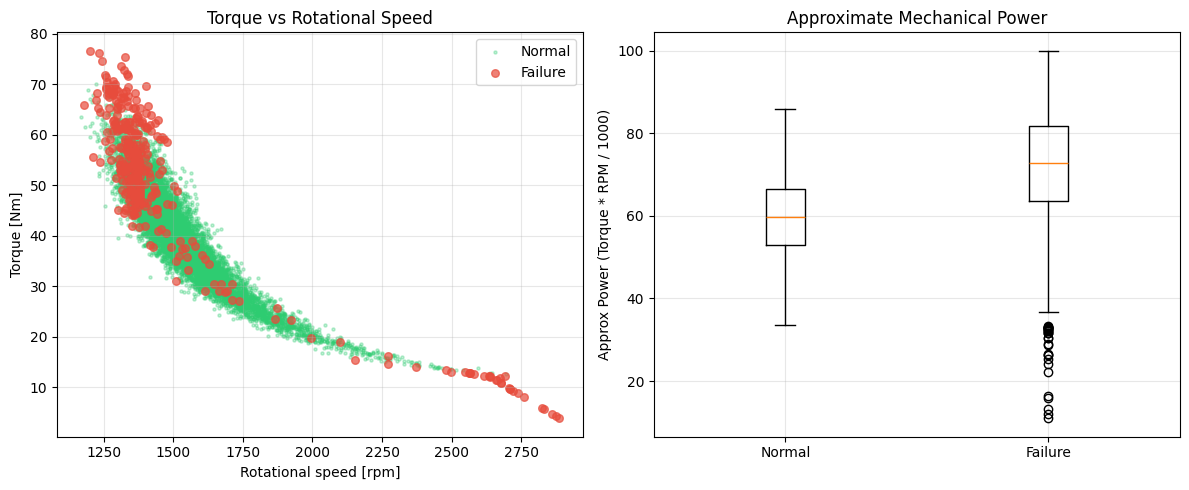

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Use the pre-computed approx_power column
axes[0].scatter(normal_df['Rotational speed [rpm]'], normal_df['Torque [Nm]'],
                c='#2ecc71', alpha=0.3, s=5, label='Normal')
axes[0].scatter(fail_df['Rotational speed [rpm]'], fail_df['Torque [Nm]'],
                c='#e74c3c', alpha=0.7, s=30, label='Failure')
axes[0].set_xlabel("Rotational speed [rpm]")
axes[0].set_ylabel("Torque [Nm]")
axes[0].set_title("Torque vs Rotational Speed")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot([normal_df['approx_power'], fail_df['approx_power']],
               labels=['Normal', 'Failure'])
axes[1].set_ylabel("Approx Power (Torque * RPM / 1000)")
axes[1].set_title("Approximate Mechanical Power")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observation**: Failed machines operate in a distinct region -- **high torque, low speed** (high load, low speed). The approximate mechanical power is similar, but the *operating point* is different. This is a classic signature of overstrain conditions.

## What We Learned

1. **Machine type matters**: Type H fails more often (4.5% vs 3.3% for L/M). Different types = different failure modes.
2. **Tool wear is the strongest signal**: 94% higher in failures, failure rate climbs from ~0% to >15% across wear range.
3. **Torque is the second signal**: 41% higher in failures, especially when combined with high tool wear.
4. **Rotational speed**: Failed machines run slower (-10%), suggesting high-load/low-speed operation.
5. **Temperatures**: Weak direct correlation, but process temp slightly higher in failures.
6. **Failure modes**: HDF and OSF dominate; Type H -> heat/overstrain, Type L -> tool wear.
7. **Key interaction**: High torque + high tool wear = failure zone.

---

**Next**: In Notebook 03, we'll build and tune statistical ML models (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) using these insights. We'll use stratified splits, cross-validation, and optimize for recall -- the right metric for predictive maintenance.